## KMeans Clustering

### What is KMeans?

“If I don’t have labels, can the data group itself?”

It is an unsupervised learning algorithm:
- no y
- no correct answers
- only patterns

### What KMeans tries to do

Given only X, KMeans tries to:

- divide data into K groups
- make points in the same group close to each other
- make different groups far apart

Each group is called a cluster.

### Intuition (before math)

Think of:
- customers
- students
- products

Even without labels, they naturally form groups.

KMeans tries to discover those groups automatically.

<img src="Images/KMeans.png">

- dots = data points
- X or star = centroid (center of a cluster)
- color = cluster assignment

### What is a centroid?

A centroid is:
- the mean position of all points in a cluster

$$
\text{centroid} = \frac{1}{n} \sum x_i
$$

Each cluster has one centroid.

### How KMeans works (algorithm steps)

- choose K centroids randomly
- assign each point to the nearest centroid
- recompute centroids as the mean of assigned points
- repeat until centroids stop moving

### Why it’s called K-Means

- K → number of clusters (you choose this)
- Means → centroids are means of points

### Minimal KMeans example (code)

In [36]:
import seaborn as sns
from sklearn.cluster import KMeans

df = sns.load_dataset("iris")

X = df[["sepal_length", "sepal_width"]]

km = KMeans(n_clusters=3, random_state=42)
km.fit(X)

labels = km.labels_
centroids = km.cluster_centers_

- n_clusters=3 → assume 3 groups
- labels_ → cluster index for each point
- cluster_centers_ → coordinates of centroids

### What labels_ means

If:

labels = [0, 0, 1, 2, 1, ...]


Then:
- points with label 0 belong to cluster 0
- labels are not ordered or meaningful
- cluster 2 is not “better” than cluster 0

They are just IDs.

## Elbow Method

KMeans forces you to choose K.

Question:

- How many clusters should I use?

The Elbow Method gives a visual answer.

### Core idea

- try many values of K
- compute how compact clusters are
- plot K vs error
- look for a bend (elbow)

After the elbow:
- adding more clusters gives diminishing returns

### The metric used: inertia

Inertia = sum of squared distances from points to their centroid.

$$
\text{Inertia} = \sum ||x_i - c_{cluster(i)}||^2
$$

Where:
- <i>x<sub>i</sub></i> = data point
- <i>c<sub>cluster(i)</sub></i> = centroid of the cluster it belongs to

small inertia → points are close to their centroids
<br>
large inertia → points are spread out

### Step 1: Prepare data + scale it

In [37]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = sns.load_dataset("iris")

X = df[["sepal_length", "sepal_width"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Why scaling?
- KMeans uses distance
- unscaled features distort clusters

### Step 2: Compute inertia for multiple K

In [38]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

- fit KMeans for each K
- store inertia_ (cluster tightness)

### Step 3: Plot the Elbow curve

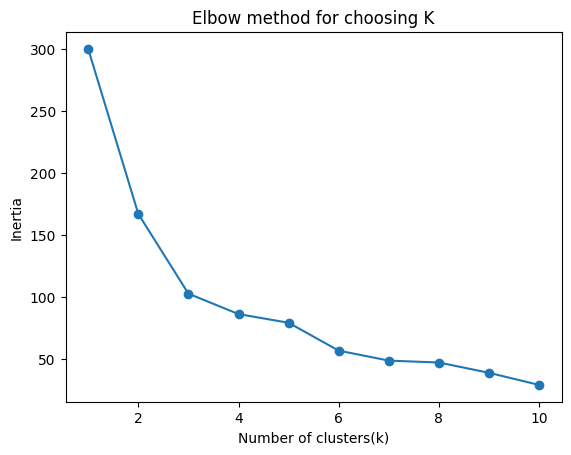

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters(k)")
plt.ylabel("Inertia")
plt.title("Elbow method for choosing K")
plt.show()

### How to read the plot

Look for:
- sharp drop initially
- then a bend
- then a flatter curve

That bend = optimal K

In the above example k=3 is the best value

Meaning:
- before elbow → clusters improving a lot
- after elbow → mostly noise reduction

- inertia always decreases as K increases
- so “lowest inertia” is meaningless
- we want balance, not minimum

The elbow = best tradeoff.

### What if there is no clear elbow?

- data may not have strong cluster structure
- KMeans may not be the best algorithm
- clustering may not be meaningful

This itself is a valid insight.

## Visualizing Clusters

### Step 1: Fit KMeans with chosen K

In [40]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)
km.fit(X_scaled)

labels = km.labels_
centroids = km.cluster_centers_

print(centroids)

[[ 1.12823615  0.12760411]
 [-0.07270072 -0.93340526]
 [-1.00206653  0.90625492]]


### Step 2: Create a DataFrame for easy plotting

In [41]:
import pandas as pd

plot_df = pd.DataFrame(X_scaled, columns=["sepal_length", "sepal_width"])
plot_df["cluster"] = labels

Why:

- makes plotting cleaner
- easier to color by cluster

### Step 3: Scatter plot of clusters

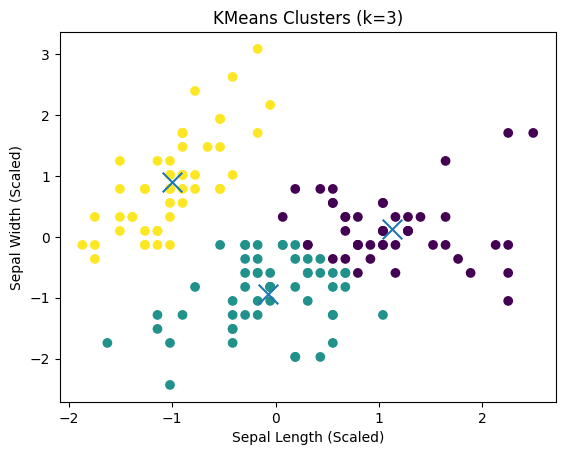

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    plot_df["sepal_length"],
    plot_df["sepal_width"],
    c = plot_df["cluster"]      # color
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=200       # size
)

plt.title("KMeans Clusters (k=3)")
plt.xlabel("Sepal Length (Scaled)")
plt.ylabel("Sepal Width (Scaled)")
plt.show()

c stands for color.

Means:

color each point based on its cluster label

cluster labels are 0, 1, 2 <br>
so there will be data points of 3 different colors.

centroids is a 2D array like this:
<pre>
[
  [x1, y1],
  [x2, y2],
  [x3, y3]
]
</pre>

Because:

- 3 clusters
- 2 features (sepal length, sepal width)

**centroids[:, 0]**

Syntax:

`array[rows, columns]`

- : → all rows
- 0 → first column

So, centroids[:, 0] means:

“Give me the x-coordinates of all centroids”

That results in:

`[x1, x2, x3]`

Similarly: centroids[:, 1]

Means:

“Give me the y-coordinates of all centroids”

Result:

`[y1, y2, y3]`

### What you can DO with this

#### Understand your current data

For the current dataset, this helps you:

- see if natural groupings exist

- check if features are meaningful

- understand relationships visually

Example interpretations (hypothetical, but realistic):

- cluster 1 → small sepal length, large width

- cluster 2 → medium values

- cluster 3 → large sepal length, smaller width

This is exploratory insight, not prediction.

#### Turn clusters into a NEW feature

This is where it becomes powerful.

You can add:

cluster_id

as a new column in your dataset.

That means:

- each row now has a group identity

- supervised models can use this information

This is feature engineering.

#### Use it for future / unseen data

This is critical:

- KMeans is not just for current data

Once trained:

`kmeans.fit(X_scaled)`


You can later do:

`new_labels = kmeans.predict(new_X_scaled)`


So for future data:

- you scale it using the same scaler

- assign it to the nearest centroid

- instantly know which group it belongs to

This is how clustering is used in:

- customer segmentation

- user profiling

- anomaly detection

- recommendation systems

## PCA (Principal Component Analysis)

### The problem PCA solves

- real datasets usually have many features
- humans can only visualize 2D or 3D
- PCA helps compress data while keeping structure

Core question PCA answers:

How can I reduce dimensions without losing the main patterns?

### What PCA does (intuition)

- PCA finds directions with maximum variance
- these directions are called principal components
- data is projected onto these new axes
- low-variance directions are dropped because they carry the same patterns

Important:
- PCA is unsupervised
- PCA does not use labels
- PCA does not try to separate clusters

### What are principal components

**PC1**
- direction with the highest variance

**PC2**
- direction with the second highest variance
- perpendicular to PC1

**PCs are:**
- new axes
- combinations of original features
- not original columns

### Why PCA + KMeans are used together

- KMeans works in high dimensions
- visualization does not

So we:
- cluster in original (scaled) space
- visualize in PCA space

PCA is for understanding, not clustering.

### Step 1: Apply PCA

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(X_scaled)

- n_components=2 → reduce to 2 dimensions
- X_pca shape becomes (n_samples, 2)

### Step 2: Store PCA output in a DataFrame

In [47]:
import pandas as pd

pca_df = pd.DataFrame(
    x_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = labels

Now each row contains:
- PC1 value
- PC2 value
- cluster assignment

### Step 3: Visualize clusters in PCA space

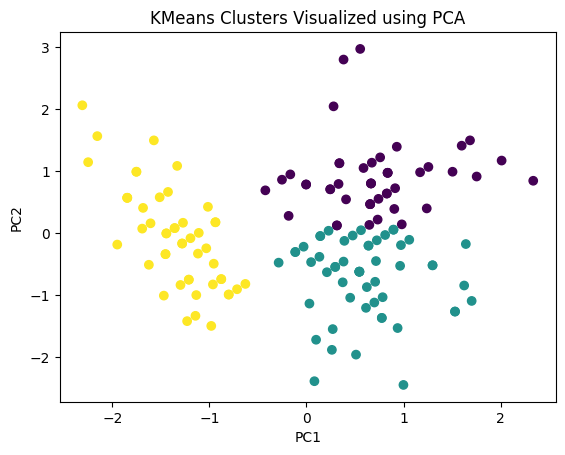

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c = pca_df["cluster"]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters Visualized using PCA")
plt.show()

What this plot shows:
- each point = one data sample
- color = cluster label
- distance ≈ similarity

### Explained variance

In [52]:
pca.explained_variance_ratio_

array([0.55878489, 0.44121511])

Meaning:
- PC1 explains 55.87% of variance
- PC2 explains 44.1% of variance
- total variance preserved ≈ 100%

This tells you how much information PCA kept.

### What PCA does NOT do

- does NOT improve clustering
- does NOT change cluster assignments
- does NOT use target labels

Clusters were already decided before PCA.

### When PCA is useful

- visualization
- noise reduction
- speeding up models
- reducing multicollinearity